# climasus4py — Exemplos de Uso

Notebook demonstrando as principais funcionalidades do pacote `climasus4py`.

**Instalação:**
```bash
pip install "climasus4py @ git+https://github.com/climasus/climasus4py.git"
```

O pacote instala automaticamente o `climasus-data` (catálogo de metadados compartilhado com o R).

---
## 1. Exploração de Metadados

Antes de qualquer análise, explore os sistemas SUS disponíveis, grupos de doenças, regiões e UFs.

In [35]:
from climasus.utils.explore import sus_explore

# Sistemas SUS disponíveis
sistemas = sus_explore("systems")
for name, info in list(sistemas.items())[:5]:
    print(f"{name}: {info.get('full_name', '')}")

SIM-DO: {'pt': 'Sistema de Informações sobre Mortalidade - Declarações de Óbito', 'en': 'Mortality Information System - Death Certificates', 'es': 'Sistema de Información sobre Mortalidad - Certificados de Defunción'}
SIM-DOFET: {'pt': 'Sistema de Informações sobre Mortalidade - Óbitos Fetais', 'en': 'Mortality Information System - Fetal Deaths', 'es': 'Sistema de Información sobre Mortalidad - Muertes Fetales'}
SIM-DOEXT: {'pt': 'Sistema de Informações sobre Mortalidade - Óbitos por Causas Externas', 'en': 'Mortality Information System - External Causes Deaths', 'es': 'Sistema de Información sobre Mortalidad - Muertes por Causas Externas'}
SIM-DOINF: {'pt': 'Sistema de Informações sobre Mortalidade - Óbitos Infantis', 'en': 'Mortality Information System - Infant Deaths', 'es': 'Sistema de Información sobre Mortalidad - Muertes Infantiles'}
SIM-DOMAT: {'pt': 'Sistema de Informações sobre Mortalidade - Óbitos Maternos', 'en': 'Mortality Information System - Maternal Deaths', 'es': 'Sist

In [36]:
# Códigos UF
ufs = sus_explore("uf")
for code, info in list(ufs.items())[:10]:
    print(f"{code}: {info['name']} ({info['region']})")

AC: {'pt': 'Acre', 'en': 'Acre', 'es': 'Acre'} (norte)
AL: {'pt': 'Alagoas', 'en': 'Alagoas', 'es': 'Alagoas'} (nordeste)
AP: {'pt': 'Amapá', 'en': 'Amapá', 'es': 'Amapá'} (norte)
AM: {'pt': 'Amazonas', 'en': 'Amazonas', 'es': 'Amazonas'} (norte)
BA: {'pt': 'Bahia', 'en': 'Bahia', 'es': 'Bahia'} (nordeste)
CE: {'pt': 'Ceará', 'en': 'Ceará', 'es': 'Ceará'} (nordeste)
DF: {'pt': 'Distrito Federal', 'en': 'Federal District', 'es': 'Distrito Federal'} (centro_oeste)
ES: {'pt': 'Espírito Santo', 'en': 'Espírito Santo', 'es': 'Espírito Santo'} (sudeste)
GO: {'pt': 'Goiás', 'en': 'Goiás', 'es': 'Goiás'} (centro_oeste)
MA: {'pt': 'Maranhão', 'en': 'Maranhão', 'es': 'Maranhão'} (nordeste)


In [4]:
# Regiões brasileiras
regioes = sus_explore("regions")
for cat_name, cat in regioes.items():
    print(f"\n--- {cat_name} ---")
    for reg_name, reg_data in cat.get("regions", {}).items():
        print(f"  {reg_name}: {reg_data['states']}")


--- ibge_macro ---
  norte: ['AC', 'AP', 'AM', 'PA', 'RO', 'RR', 'TO']
  nordeste: ['AL', 'BA', 'CE', 'MA', 'PB', 'PE', 'PI', 'RN', 'SE']
  centro_oeste: ['DF', 'GO', 'MT', 'MS']
  sudeste: ['ES', 'MG', 'RJ', 'SP']
  sul: ['PR', 'RS', 'SC']

--- biomes ---
  amazonia_legal: ['AC', 'AP', 'AM', 'PA', 'RO', 'RR', 'MT', 'MA', 'TO']
  mata_atlantica: ['AL', 'BA', 'CE', 'ES', 'GO', 'MA', 'MG', 'MS', 'PB', 'PE', 'PI', 'PR', 'RJ', 'RN', 'RS', 'SC', 'SE', 'SP']
  caatinga: ['AL', 'BA', 'CE', 'MA', 'PB', 'PE', 'PI', 'RN', 'SE', 'MG']
  cerrado: ['BA', 'DF', 'GO', 'MA', 'MG', 'MS', 'MT', 'PA', 'PI', 'PR', 'RO', 'SP', 'TO']
  pantanal: ['MT', 'MS']
  pampa: ['RS']

--- hydrography ---
  bacia_amazonica: ['AC', 'AM', 'AP', 'MT', 'PA', 'RO', 'RR']
  bacia_sao_francisco: ['AL', 'BA', 'DF', 'GO', 'MG', 'PE', 'SE']
  bacia_parana: ['GO', 'MG', 'MS', 'PR', 'SP']
  bacia_tocantins: ['GO', 'MA', 'PA', 'TO']

--- climate ---
  semi_arido: ['AL', 'BA', 'CE', 'MA', 'PB', 'PE', 'PI', 'RN', 'SE', 'MG']

--- h

In [5]:
# Grupos de doenças
#groups = sus_explore("groups")
#print("Grupos core:", [g['name'] for g in groups["core"]["groups"]])
#print("\nGrupos climáticos:", [g['name'] for g in groups["climate_sensitive"]["groups"]])

---
## 2. Pipeline Completo (forma mais comum de uso)

`sus_pipeline()` executa o ETL inteiro em uma única chamada:  
`import → clean → standardize → filter → variables → aggregate`

In [45]:
from climasus.core.pipeline import sus_pipeline

# Mortalidade (SIM-DO) em São Paulo, 2023, agregado por mês e estado
result = sus_pipeline(
    system="SIM-DO",
    uf="SP",
    year=2023,
    lang="pt",         # Rótulos em português
    time="month",      # Agregação mensal
    geo="state",       # Agregação por estado
)

# O resultado é uma relação DuckDB (lazy). Para materializar:
df = result.df()
print(f"Shape: {df.shape}")
df.head()

Shape: (12, 3)


,time_group,state,count
0,2023-01,35,26556
1,2023-02,35,23347
2,2023-03,35,27446
3,2023-04,35,26995
4,2023-05,35,29585


In [38]:
# Pipeline com filtro por grupo de doenças respiratórias
resp = sus_pipeline(
    system="SIM-DO",
    uf="SP",
    year=2023,
    lang="en",
    groups="respiratory",   # Filtra apenas doenças respiratórias
    time="month",
    geo="state",
)
resp.df().head()

,time_group,state,count
0,2023-01,35,2827
1,2023-02,35,2538
2,2023-03,35,3225
3,2023-04,35,3405
4,2023-05,35,3936


In [39]:
# Pipeline com faixa etária e múltiplos estados
result_age = sus_pipeline(
    system="SIM-DO",
    uf=["SP", "RJ", "MG"],
    year=[2022, 2023],
    lang="en",
    age_min=60,
    age_max=100,
    age_group="decadal",   # Faixas: 60-69, 70-79, 80-89, 90-99, 100+
    time="year",
    geo="state",
)
result_age.df().head(10)

,time_group,count
0,<NA>,17


In [40]:
# Pipeline com faixas etárias personalizadas
result_custom = sus_pipeline(
    system="SIM-DO",
    uf="SP",
    year=2023,
    lang="pt",
    age_group=[0, 5, 18, 40, 65, 120],  # Faixas customizadas
    time="month",
    geo="state",
)
result_custom.df().head()

,time_group,count
0,None,1244


---
## 3. Uso Passo a Passo (funções individuais)

Para maior controle, execute cada etapa separadamente.

### 3.1 Importação

In [46]:
from climasus.core.importer import sus_import

# Importa dados do SIM-DO para SP, 2023 (baixa e cacheia automaticamente)
raw = sus_import(system="SIM-DO", uf="SP", year=2023)

# O resultado é uma relação DuckDB lazy — nada materializado ainda
print(f"Tipo: {type(raw)}")
print(f"Colunas: {raw.columns}")
print(f"Linhas (estimativa): {raw.count('*').fetchone()[0]:,}")
raw

Tipo: <class '_duckdb.DuckDBPyRelation'>
Colunas: ['ORIGEM', 'TIPOBITO', 'DTOBITO', 'HORAOBITO', 'NATURAL', 'CODMUNNATU', 'DTNASC', 'IDADE', 'SEXO', 'RACACOR', 'ESTCIV', 'ESC', 'ESC2010', 'SERIESCFAL', 'OCUP', 'CODMUNRES', 'LOCOCOR', 'CODESTAB', 'ESTABDESCR', 'CODMUNOCOR', 'IDADEMAE', 'ESCMAE', 'ESCMAE2010', 'SERIESCMAE', 'OCUPMAE', 'QTDFILVIVO', 'QTDFILMORT', 'GRAVIDEZ', 'SEMAGESTAC', 'GESTACAO', 'PARTO', 'OBITOPARTO', 'PESO', 'TPMORTEOCO', 'OBITOGRAV', 'OBITOPUERP', 'ASSISTMED', 'EXAME', 'CIRURGIA', 'NECROPSIA', 'LINHAA', 'LINHAB', 'LINHAC', 'LINHAD', 'LINHAII', 'CAUSABAS', 'CB_PRE', 'COMUNSVOIM', 'DTATESTADO', 'CIRCOBITO', 'ACIDTRAB', 'FONTE', 'NUMEROLOTE', 'TPPOS', 'DTINVESTIG', 'CAUSABAS_O', 'DTCADASTRO', 'ATESTANTE', 'STCODIFICA', 'CODIFICADO', 'VERSAOSIST', 'VERSAOSCB', 'FONTEINV', 'DTRECEBIM', 'ATESTADO', 'DTRECORIGA', 'CAUSAMAT', 'ESCMAEAGR1', 'ESCFALAGR1', 'STDOEPIDEM', 'STDONOVA', 'DIFDATA', 'NUDIASOBCO', 'NUDIASOBIN', 'DTCADINV', 'TPOBITOCOR', 'DTCONINV', 'FONTES', 'TPRESGI

┌─────────┬──────────┬──────────┬───────────┬─────────┬────────────┬──────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬────────────┬─────────┬───────────┬─────────┬──────────┬────────────┬────────────┬──────────┬─────────┬────────────┬────────────┬─────────┬────────────┬────────────┬──────────┬────────────┬──────────┬─────────┬────────────┬─────────┬────────────┬───────────┬────────────┬───────────┬─────────┬──────────┬───────────┬─────────┬────────────┬────────────┬─────────┬────────────┬──────────┬─────────┬────────────┬────────────┬───────────┬──────────┬─────────┬────────────┬─────────┬────────────┬────────────┬────────────┬───────────┬────────────┬────────────┬────────────┬───────────┬──────────┬───────────┬───────────────────────────────────┬────────────┬──────────┬────────────┬────────────┬────────────┬──────────┬─────────┬────────────┬────────────┬──────────┬────────────┬──────────┬─────────┬────────────┬────────────┬───────────┬──────────┬────────────┬─────

In [42]:
# Importar de um arquivo parquet local
raw_local = sus_import(system="SIM-DO", uf="SP", year=2023,
                        path="dados/cache/SIM-DO/file_SP_2023.parquet")
print(f"Linhas após limpeza: {raw_local.count('*').fetchone()[0]:,}")

raw_local

Linhas após limpeza: 334,303


┌─────────┬──────────┬──────────┬───────────┬─────────┬────────────┬──────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬────────────┬─────────┬───────────┬─────────┬──────────┬────────────┬────────────┬──────────┬─────────┬────────────┬────────────┬─────────┬────────────┬────────────┬──────────┬────────────┬──────────┬─────────┬────────────┬─────────┬────────────┬───────────┬────────────┬───────────┬─────────┬──────────┬───────────┬─────────┬────────────┬────────────┬─────────┬────────────┬──────────┬────────┬────────────┬────────────┬───────────┬──────────┬─────────┬────────────┬─────────┬────────────┬────────────┬────────────┬───────────┬────────────┬────────────┬────────────┬───────────┬──────────┬───────────┬───────────────────────────────────┬────────────┬──────────┬────────────┬────────────┬────────────┬──────────┬─────────┬────────────┬────────────┬──────────┬────────────┬──────────┬─────────┬────────────┬────────────┬───────────┬──────────┬────────────┬──────

### 3.2 Limpeza

In [43]:
from climasus.core.clean import sus_clean

# Limpa: deduplica, corrige encoding, valida idades
clean = sus_clean(raw, fix_enc=True, dedup=True, age_range=(0, 120))
print(f"Linhas após limpeza: {clean.count('*').fetchone()[0]:,}")
clean

Linhas após limpeza: 1,244


┌─────────┬──────────┬──────────┬───────────┬─────────┬────────────┬──────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬────────────┬─────────┬───────────┬─────────┬──────────┬────────────┬────────────┬──────────┬─────────┬────────────┬────────────┬─────────┬────────────┬────────────┬──────────┬────────────┬──────────┬─────────┬────────────┬─────────┬────────────┬───────────┬────────────┬───────────┬─────────┬──────────┬───────────┬─────────┬────────────┬─────────┬─────────┬────────────┬──────────┬─────────┬────────────┬────────────┬───────────┬──────────┬─────────┬────────────┬─────────┬────────────┬────────────┬────────────┬───────────┬────────────┬────────────┬────────────┬───────────┬──────────┬───────────┬──────────────────────────────┬────────────┬──────────┬────────────┬────────────┬────────────┬──────────┬─────────┬────────────┬────────────┬──────────┬────────────┬──────────┬─────────┬────────────┬────────────┬───────────┬──────────┬────────────┬───────────┬─

In [44]:
# Conversão explícita de datas antes da padronização
import pandas as pd

df_clean = clean.df().copy()
for col in ["DTNASC", "DTOBITO"]:
    if col in df_clean.columns:
        df_clean[col] = pd.to_datetime(df_clean[col], format="%d%m%Y", errors="coerce")

print("Amostra após conversão de datas:")
print(df_clean[[c for c in ["DTNASC", "DTOBITO"] if c in df_clean.columns]].head())

Amostra após conversão de datas:
      DTNASC    DTOBITO
0 2023-11-12 2023-11-12
1 2023-11-12 2023-11-13
2 2023-11-21 2023-11-21
3 2023-11-22 2023-11-22
4 2023-11-30 2023-11-30


### 3.3 Padronização

In [28]:
from climasus.core.standardize import sus_standardize

# Padroniza nomes de colunas e traduz rótulos
std = sus_standardize(clean, lang="en")  # "pt", "en", "es"
print("Colunas padronizadas:", std.columns)
std

Colunas padronizadas: ['record_origin', 'death_type', 'death_date', 'death_time', 'birthplace_municipality', 'birthplace_municipality_code', 'birth_date', 'age', 'sex', 'race', 'marital_status', 'education', 'education_2010', 'deceased_education_grade', 'occupation', 'residence_municipality_code', 'death_location', 'health_facility_code', 'ESTABDESCR', 'occurrence_municipality_code', 'mother_age', 'mother_education', 'mother_education_2010', 'mother_education_grade', 'mother_occupation', 'number_of_living_children', 'number_of_dead_children', 'pregnancy_type', 'gestational_weeks', 'gestational_age', 'delivery_type', 'death_timing_delivery', 'birth_weight', 'TPMORTEOCO', 'OBITOGRAV', 'OBITOPUERP', 'medical_assistance', 'examination_performed', 'surgery_performed', 'autopsy', 'cause_line_a', 'cause_line_b', 'cause_line_c', 'cause_line_d', 'cause_line_ii', 'underlying_cause', 'pre_selection_underlying_cause', 'COMUNSVOIM', 'DTATESTADO', 'death_circumstance', 'work_accident', 'information_

┌───────────────┬────────────┬────────────┬────────────┬─────────────────────────┬──────────────────────────────┬────────────┬─────────┬─────────┬─────────┬────────────────┬───────────┬────────────────┬──────────────────────────┬────────────┬─────────────────────────────┬────────────────┬──────────────────────┬────────────┬──────────────────────────────┬────────────┬──────────────────┬───────────────────────┬────────────────────────┬───────────────────┬───────────────────────────┬─────────────────────────┬────────────────┬───────────────────┬─────────────────┬───────────────┬───────────────────────┬──────────────┬────────────┬───────────┬────────────┬────────────────────┬───────────────────────┬───────────────────┬─────────┬──────────────┬──────────────┬──────────────┬──────────────┬───────────────┬──────────────────┬────────────────────────────────┬────────────┬────────────┬────────────────────┬───────────────┬────────────────────┬──────────────┬────────────────────┬──────────────────

In [33]:
# Diagnóstico: tipos e amostras antes/depois da padronização
print("Tipos antes da padronização:")
print(clean.df().dtypes)
print("Amostra antes da padronização:")
print(clean.df().head())

std = sus_standardize(clean, lang="en")  # "pt", "en", "es"

print("Tipos depois da padronização:")
print(std.df().dtypes)
print("Amostra depois da padronização:")
print(std.df().head())

Tipos antes da padronização:
ORIGEM        object
TIPOBITO      object
DTOBITO       object
HORAOBITO     object
NATURAL       object
               ...  
MORTEPARTO    object
DTCONCASO     object
FONTESINF     object
ALTCAUSA      object
CONTADOR      object
Length: 87, dtype: object
Amostra antes da padronização:
  ORIGEM TIPOBITO   DTOBITO HORAOBITO NATURAL CODMUNNATU    DTNASC IDADE SEXO  \
0      1        2  01012023      0825     835     355030  01012023   001    2   
1      1        2  02012023      1515     835     354850  02012023   023    1   
2      1        2  03012023      2055     835     352930  03012023   104    2   
3      1        2  04012023      2120     835     353070  04012023   120    1   
4      1        2  04012023      1406     835     354140  04012023   101    1   

  RACACOR  ...  FONTES TPRESGINFO TPNIVELINV NUDIASINF  DTCADINF MORTEPARTO  \
0       1  ...  XXSXXX                                  18052023          3   
1       4  ...  XXSXXX                

### 3.4 Filtragem

In [14]:
from climasus.core.filter import sus_filter

# Filtrar por grupo de doenças
filtered = sus_filter(std, groups="cardiovascular")
print(f"Linhas cardiovascular: {filtered.count('*').fetchone()[0]:,}")

Linhas cardiovascular: 0


In [15]:
# Filtrar por códigos CID-10 específicos
filtered_cid = sus_filter(std, codes=["I21", "I22", "J12-J18"])
print(f"Linhas IAM + pneumonia: {filtered_cid.count('*').fetchone()[0]:,}")

Linhas IAM + pneumonia: 0


In [16]:
# Filtragem combinada: demografia + período
filtered_demo = sus_filter(
    std,
    groups="respiratory",
    age_min=65,
    sex="F",
    date_start="2023-06-01",
    date_end="2023-08-31",
)
print(f"Idosas com resp. no inverno: {filtered_demo.count('*').fetchone()[0]:,}")

Idosas com resp. no inverno: 0


### 3.5 Variáveis derivadas

In [17]:
from climasus.core.variables import sus_variables

# Criar faixas etárias WHO, semana epidemiológica e estação do ano
enriched = sus_variables(
    std,
    age_group="who",      # Faixas etárias OMS
    epi_week=True,         # Semana epidemiológica
    season=True,           # Estação do ano
    quarter=True,          # Trimestre
)
print("Novas colunas:", enriched.columns)

Novas colunas: ['record_origin', 'death_type', 'death_date', 'death_time', 'birthplace_municipality', 'birthplace_municipality_code', 'birth_date', 'age', 'sex', 'race', 'marital_status', 'education', 'education_2010', 'deceased_education_grade', 'occupation', 'residence_municipality_code', 'death_location', 'health_facility_code', 'ESTABDESCR', 'occurrence_municipality_code', 'mother_age', 'mother_education', 'mother_education_2010', 'mother_education_grade', 'mother_occupation', 'number_of_living_children', 'number_of_dead_children', 'pregnancy_type', 'gestational_weeks', 'gestational_age', 'delivery_type', 'death_timing_delivery', 'birth_weight', 'TPMORTEOCO', 'OBITOGRAV', 'OBITOPUERP', 'medical_assistance', 'examination_performed', 'surgery_performed', 'autopsy', 'cause_line_a', 'cause_line_b', 'cause_line_c', 'cause_line_d', 'cause_line_ii', 'underlying_cause', 'pre_selection_underlying_cause', 'COMUNSVOIM', 'DTATESTADO', 'death_circumstance', 'work_accident', 'information_source'

### 3.6 Agregação

In [18]:
from climasus.core.aggregate import sus_aggregate

# Agregar por mês e município
agg = sus_aggregate(std, time="month", geo="municipality")
agg.df().head(10)

,time_group,count
0,None,1244


---
## 4. Exportação

In [19]:
from climasus.io.export import sus_export

# Exportar para Parquet (mais rápido, menor tamanho)
# sus_export(agg, "output/mortalidade_sp_2023.parquet")

# Exportar para CSV
# sus_export(agg, "output/mortalidade_sp_2023.csv")

# Exportar para Excel (requer pip install climasus4py[excel])
# sus_export(agg, "output/mortalidade_sp_2023.xlsx")

print("Descomente as linhas acima para exportar.")

Descomente as linhas acima para exportar.


---
## 5. Materialização eficiente (Arrow vs Pandas)

In [20]:
from climasus.core.engine import collect_arrow

# Todos os resultados são relações DuckDB (lazy). Para materializar:

result = sus_pipeline(system="SIM-DO", uf="SP", year=2023, time="month", geo="state")

# Opção 1: Pandas DataFrame
df_pandas = result.df()
print(f"Pandas: {type(df_pandas)} — {df_pandas.shape}")

# Opção 2: PyArrow Table (mais eficiente para dados grandes)
table_arrow = collect_arrow(result)
table_arrow = table_arrow.read_all()  # Converte para pyarrow.Table
print(f"Arrow:  {type(table_arrow)} — {table_arrow.num_rows} linhas, {table_arrow.num_columns} colunas")

Pandas: <class 'pandas.core.frame.DataFrame'> — (12, 3)
Arrow:  <class 'pyarrow.lib.Table'> — 12 linhas, 3 colunas


---
## 6. Cache

In [21]:
from climasus.io.cache import sus_cache_info, sus_cache_clear

# Ver arquivos em cache
cache = sus_cache_info()
print(f"Arquivos em cache: {len(cache)}")
cache

Arquivos em cache: 10


,file,path,size_mb,modified
0,AC_2023_all.parquet,dados\cache\SIM-DO\AC_2023_all.parquet,0.31,2026-04-14T22:58:03
1,ES_2023_all.parquet,dados\cache\SIM-DO\ES_2023_all.parquet,1.53,2026-04-15T22:14:20
2,file_SP_2023.parquet,dados\cache\SIM-DO\file_SP_2023.parquet,15.73,2026-04-16T08:13:04
3,inline_SP_2023.parquet,dados\cache\SIM-DO\inline_SP_2023.parquet,0.05,2026-04-15T21:17:48
4,MG_2022_all.parquet,dados\cache\SIM-DO\MG_2022_all.parquet,7.91,2026-04-15T21:53:13
5,MG_2023_all.parquet,dados\cache\SIM-DO\MG_2023_all.parquet,7.88,2026-04-15T21:54:19
6,RJ_2022_all.parquet,dados\cache\SIM-DO\RJ_2022_all.parquet,6.97,2026-04-15T21:50:49
7,RJ_2023_all.parquet,dados\cache\SIM-DO\RJ_2023_all.parquet,6.82,2026-04-15T21:51:56
8,SP_2022_all.parquet,dados\cache\SIM-DO\SP_2022_all.parquet,17.11,2026-04-15T21:49:39
9,SP_2023_all.parquet,dados\cache\SIM-DO\SP_2023_all.parquet,16.31,2026-04-15T21:35:20


In [22]:
# Limpar cache (descomente para executar)

# Limpar tudo
# sus_cache_clear()

# Limpar apenas SIM-DO
# sus_cache_clear(system="SIM-DO")

# Limpar apenas SP
# sus_cache_clear(uf="SP")

---
## 7. Utilitários

In [23]:
from climasus.utils.data import resolve_uf

# Resolver especificações de UF
print("Um estado:", resolve_uf("SP"))
print("Vários:", resolve_uf(["SP", "RJ", "MG"]))
print("Todos:", resolve_uf("all"))

Um estado: ['SP']
Vários: ['SP', 'RJ', 'MG']
Todos: ['AC', 'AL', 'AP', 'AM', 'BA', 'CE', 'DF', 'ES', 'GO', 'MA', 'MT', 'MS', 'MG', 'PA', 'PB', 'PR', 'PE', 'PI', 'RJ', 'RN', 'RS', 'RO', 'RR', 'SC', 'SP', 'SE', 'TO']


In [34]:
from climasus.utils.cid import expand_cid_range

# Expandir ranges CID-10
print("J12-J18:", expand_cid_range("J12", "J18"))
print("I20-I25:", expand_cid_range("I20", "I25"))

J12-J18: ['J12', 'J13', 'J14', 'J15', 'J16', 'J17', 'J18']
I20-I25: ['I20', 'I21', 'I22', 'I23', 'I24', 'I25']


In [25]:
# Acesso direto ao catálogo climasus-data
import climasus_data

# Carregar qualquer JSON do catálogo
systems = climasus_data.load_json("metadata/sus_systems.json")
print("Sistemas disponíveis:", list(systems["systems"].keys()))

# Caminho para um arquivo de dados
print("\nPath municípios:", climasus_data.get_path("geo/municipios.json"))

Sistemas disponíveis: ['SIM-DO', 'SIM-DOFET', 'SIM-DOEXT', 'SIM-DOINF', 'SIM-DOMAT', 'SIH-RD', 'SIH-RJ', 'SIH-SP', 'SIH-ER', 'SINAN-DENGUE', 'SINAN-CHIKUNGUNYA', 'SINAN-ZIKA', 'SINAN-MALARIA', 'SINAN-CHAGAS', 'SINAN-LEISHMANIOSE-VISCERAL', 'SINAN-LEISHMANIOSE-TEGUMENTAR', 'SINAN-LEPTOSPIROSE', 'SIA-AB', 'SIA-ABO', 'SIA-ACF', 'SIA-AD', 'SIA-AN', 'SIA-AM', 'SIA-AQ', 'SIA-AR', 'SIA-ATD', 'SIA-PA', 'SIA-PS', 'SIA-SAD', 'CNES-LT', 'CNES-ST', 'CNES-DC', 'CNES-EQ', 'CNES-SR', 'CNES-HB', 'CNES-PF', 'CNES-EP', 'CNES-RC', 'CNES-IN', 'CNES-EE', 'CNES-EF', 'CNES-GM', 'SINASC']

Path municípios: C:\Users\Readone\Desktop\CLIMA_SUS_4_R\climasus-data\geo\municipios.json


---
## 8. Exemplo Completo: Análise de Mortalidade Respiratória

Exemplo realista combinando pipeline + visualização.

In [26]:
import pandas as pd

# Pipeline: mortalidade respiratória no Sudeste, 2023, por mês e estado
resp_sudeste = sus_pipeline(
    system="SIM-DO",
    uf=["SP", "RJ", "MG", "ES"],
    year=2023,
    lang="pt",
    groups="respiratory",
    time="month",
    geo="state",
)

df = resp_sudeste.df()
print(f"Dados: {df.shape[0]} linhas, {df.shape[1]} colunas")
print(f"\nColunas: {list(df.columns)}")
df.head(12)

Dados: 48 linhas, 3 colunas

Colunas: ['time_group', 'state', 'count']


,time_group,state,count
0,2023-01,31,1388
1,2023-01,32,167
2,2023-01,33,1219
3,2023-01,35,2827
4,2023-02,31,1228
5,2023-02,32,155
6,2023-02,33,1075
7,2023-02,35,2538
8,2023-03,31,1583
9,2023-03,32,174


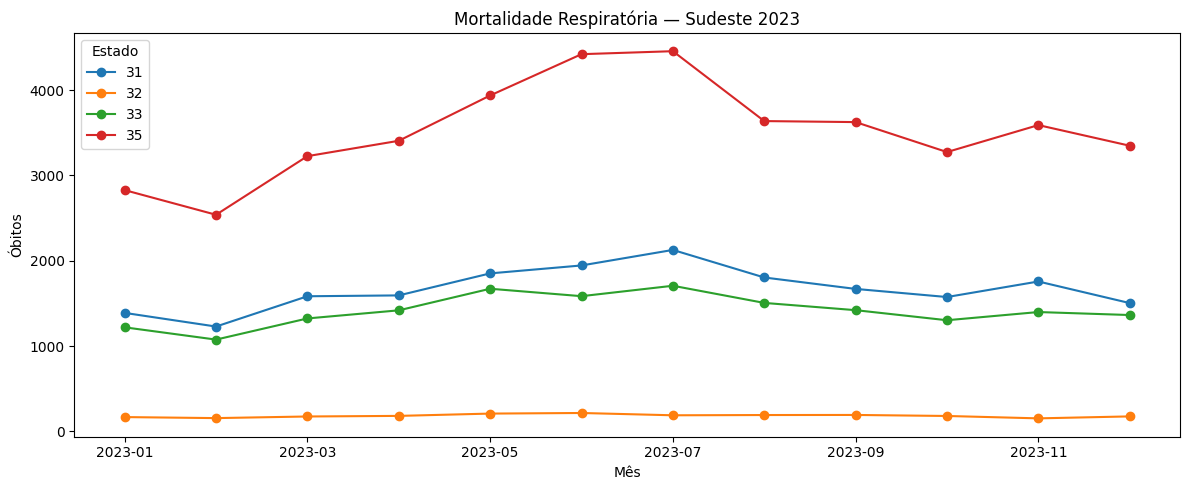

In [27]:
# Visualização simples (só precisa de matplotlib, já incluso no pandas)
try:
    import matplotlib.pyplot as plt

    if "count" in df.columns and "state" in df.columns:
        pivot = df.pivot_table(index=df.columns[0], columns="state", values="count", aggfunc="sum")
        pivot.plot(kind="line", figsize=(12, 5), marker="o")
        plt.title("Mortalidade Respiratória — Sudeste 2023")
        plt.ylabel("Óbitos")
        plt.xlabel("Mês")
        plt.legend(title="Estado")
        plt.tight_layout()
        plt.show()
    else:
        print("Colunas disponíveis:", list(df.columns))
        print("Ajuste a visualização conforme os nomes das colunas.")
except ImportError:
    print("Instale matplotlib para visualizações: pip install matplotlib")

---
## Referência Rápida

| Função | Descrição | Módulo |
|--------|-----------|--------|
| `sus_pipeline()` | Pipeline ETL completo | `climasus.core.pipeline` |
| `sus_import()` | Importar dados DATASUS | `climasus.core.importer` |
| `sus_clean()` | Limpeza (dedup, encoding) | `climasus.core.clean` |
| `sus_standardize()` | Padronizar colunas/rótulos | `climasus.core.standardize` |
| `sus_filter()` | Filtrar por CID, idade, etc. | `climasus.core.filter` |
| `sus_variables()` | Faixas etárias, epi_week | `climasus.core.variables` |
| `sus_aggregate()` | Agregar tempo/geo | `climasus.core.aggregate` |
| `sus_export()` | Exportar parquet/csv/xlsx | `climasus.io.export` |
| `sus_explore()` | Explorar metadados | `climasus.utils.explore` |
| `sus_climate()` | Juntar dados climáticos | `climasus.enrichment.climate` |
| `sus_spatial()` | Juntar shapefiles | `climasus.enrichment.spatial` |
| `sus_census()` | Juntar dados do censo | `climasus.enrichment.census` |
| `collect_arrow()` | Materializar como Arrow | `climasus.core.engine` |